## Instructions

In this assessment, you are going to develop an emperical model by fitting a curve to data, and you will use your model to make predictions.

Scores are determined by:

- Successfully starting the C Level = 50 pts
- Perfectly completing the C Level = 75 pts
- Perfectly completing the B and C Levels = 85 pts
- Perfectly completing the A, B, and C Levels = 100 pts

You may use your Colab notebooks, our textbook, my notebook solutions, and any links to web sites I provide. (You may not use any other person or web site or book or resource, in general.)

You may ask me for help **once**; however, you may ask for clarification as often as needed.

Add additional cells for both code and markdown as needed. **Write answers to questions in narrative form in markdown.** You may print values you need in your code, and then use these values in a written response.

**All graphs should have correct titles and axis labels (with units).**

### **Using resources**

You may use your Colab notebooks from class, any other notebook or reading I have given you, and any links to web sites I have provided. Basically, if it is linked on Blackboard then you can use it.

You may not use any other person, website, book, or resource. This includes the AI features in Google Colab or any other generative AI tool (ChatGPT, etc.) You are responsible for using only approved resources. If you're unsure whether something is allowed, please ask me before using it.

You can disable the Gemini AI assistance by going to settings and unchecking `Consented to use generative AI features` and checking `Hide generative AI features.` as seen below.

### **Citing Sources**

Citing sources isn't just about copying and pasting code—it's about giving credit whenever you use ideas, inspiration, or guidance from another source, even if you don't copy directly. Here's how to handle it:

- **When to Cite**:
  - If you refer to a **specific code example** from class materials, notebooks, or a reading.
    - Example: "I used the loop structure from the `02-01-random` notebook, exercise 1."
  - When you use an **idea** or approach that you didn't come up with on your own, even if you modify it.
    - Example: "The way I calculated the probability of finding the area of a circle was based on the pre-class notebook for Day 3."
  - **Even if you don't copy-paste** code, if something influenced your thinking or the way you structured your solution, it should be cited.
  
- **What doesn't need citation**:
  - Basic ideas that come entirely from your own brain.
  - Simple language constructs like loops, if-statements, or variables, unless they come directly from an example you're referencing.

- **Key points**
  - It's always better to cite than to leave something out. You won't lose points for over-citing and I will give you feedback on what citations are required or not.
  - Don't just cite when you copy code—cite when ideas or problem-solving approaches come from an outside source.

- **Examples of Correct Citations**:
  - **Copied/Modified Code**: "We used the code from the `randomwalk1D` function in the `02-03-random-walk` notebook to help structure our loop."
  - **Concept or Inspiration**: "We based our approach for determining the circle a dart landed in on the exmaple we did in class estimating $\pi$. "



## Grade

<font color="green"></font>

Level | Grade | Comment
--- | --- | ---
C (75 pts) | |
B (10 pts) | |
A (15 pts) | |
Total |


# Level C

## Exercise 0

1. Save a copy of this notebook to Google Drive. Have you already shared your Google Colabortory folder with "hpuphysicsdepartment@gmail.com"? If not, then be sure to share your folder.

2. Add a text cell above and type your name as a level one heading in markdown. (A level one heading starts with # on its own line.)

## Exercise 1

Training a machine learning model is, fundementally, a minimization procedure. What do we call the name of the function are we minimizing when we train a model? What are we changing in order to minimize that function?

## Exercise 2

In the context of a nueral network, what is a neuron? What defines the connection between two neturons in a network?

## Exercise 3

In the context of machine learning, what is an epoch? What does it mean to say "We trained the model for 20 epochs."?

## Exercise 4

Define "training set" and "validation set". Describe the purpose of using both a training and a validation set when training and evaluating a model.

# Level B

## Exercise 1

A common cost function is the mean squared error loss (or cost). This is the cost function we have used in class and seen in Sanderson's videos. Suppose we have a neural network with three output neurons. For some input data, the model outputs $\left[\frac{1}{5}, 0, \frac{2}{3}\right]$. The target (or expected) output is $[0, 0, 1]$. Calculate the value of the mean squared error cost function for this case.



## Exercise 2

In Unit 3 we examined empirical models. Describe the similarities between empirical models and neural networks. Then list one of the primary ways in which a neural network differs from the types of emperical models we have seen in the past.

## Exercise 3

Suppose you have a model that is over-trained. What would you expected long term (after many epochs of training) behavior of the cost function evaluated on both the training and validation data sets to be? You can either make a sketch, or discribe the behavior in words.

# Level A





  This section will deal with training and evaluating the results of a ML model. In this case, we will be training a model to take in a review of a movie from [IMDB](https://www.imdb.com/) and tell us if the review was favorable, or unfavorable.  I have liberally commented the code if you would like to understand what it is doing in detail, but like the notebooks from this unit I do not expect you to understand each individual line of code (we would need a whole other class for that!).

  In our work with handwritten digits, we saw how images were represented as grids of pixel intensities that the model could interpret numerically. In this problem, the input is text, which is inherently different but can be transformed into numbers using a process called encoding where each word is asigned a unique number. Just like before, these numbers become the input for our neural network, allowing it to find patterns and make predictions.

  When training neural networks, having a consistent input format is crucial. In the digit recognition problem, we used 28x28 images where every input had the same size. Here, movie reviews vary in length, so we introduce padding to ensure all reviews are the same size. This means we add placeholders words to the end of short reviews to make sure all reviews are the same length.

  The techniques you learned for digit recognition—such as defining a cost function to guide the model's learning and using a training loop to improve performance—apply directly to this problem. While the dataset and structure of the neural network differ slightly, the foundational tools and approaches remain the same and this problem will ask you to evaluate the performace of the model in the same way.

  **Read through the text descriptions of the code cells below, and run each code cell in order.**

  Run the code cell below to import the required packages and download the data. This code cell also defines two functions. `encode_review(text)` takes in a string with a movie review and returns the movie review expressed as a list of numbers. `decode_review(review)` does the opposite, it takes in a review as a list of numbers and returns the review in text form.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import string
import torch
import torch.nn.functional as F
from torch import nn
import tensorflow.keras.datasets.imdb as imdb #import our dataset

vocab_size = 10000 # How many words we want to care about

# Download the data we will use in this model.
# Each review consists of a list of numbers where each number refers to a specific
# word. To keep the data a reasonable size, we will only keep the 10000 most
# common words in the dataset. Any word that is unknown will be replaced with "<UNK>"
(train_data_raw, train_labels), (valid_data_raw, valid_labels) = imdb.load_data(num_words=vocab_size)

# Download the mapping between numbers and words and add a few special
# "words" to it that were used in creating the mapping by the authors of the dataset.
word_index = imdb.get_word_index()
word_index = {k:(v+3) for k,v in word_index.items()}
word_index["<PAD>"] = 0 # We will use this to make all the reviews the same length
word_index["<START>"] = 1 # Represents the start of a review
word_index["<UNK>"] = 2  # Represents an unknown word (not one of the top 10000 words)
word_index["<UNUSED>"] = 3 # Left for potential future use by authors of dataset

# Create a reverse lookup dictionary and define a function for getting the text of reviews
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

def decode_review(text):
    return ' '.join([reverse_word_index.get(i, '?') for i in text])
def encode_review(text):
  text = text.lower() # make string all lower case
  text = text.translate(str.maketrans("","", string.punctuation)) # remove punctuation from string
  encoded = [word_index["<START>"]]
  for word in text.split():
    if word in word_index:
      encoded.append(word_index[word])
    else:
      encoded.append(word_index["<UNK>"])
  return encoded

How our data is structured, each word corresponds to a single number. For example, the word "the" corresponds to the number 4 and the word "this" corresponds to the number 14. Run the code cell below to see some of the mappings between words and numbers.

In [ ]:
word = "is"
print(f"The word \"{word}\" corresponds to the number {word_index[word]}")

word = "movie"
print(f"The word \"{word}\" corresponds to the number {word_index[word]}")

To demonstrate this more fully, the code cell below will print out the first movie review in our training data and weather it is a positive or negative review. It will first print the review as the model will see it (just numbers) and then the review in text form based on our mapping. This uses the `decode_review` function we defined previously.

In [ ]:
review_num = 0
print(f"The first review (as the model will see it) is: {train_data_raw[review_num]}")
if train_labels[review_num] == 0:
  print(f"The review was bad")
else:
  print(f"The review was good")

print(f"The first review (decoded into text) is:")
decode_review(train_data_raw[review_num])

There is one more step we have to do before we can build the model. Each review is a different length, but as we have seen we need our input data to be a fixed size. In our digit recognition example from class, we always used the same image size of 28 X 28 pixels. Likewise, for our reviews we will need to make each review the same length. In this case we will make them all 256 words long (slightly longer than the average movie review length). Run the code cell below to make all the reviews the same length. This process is called *padding*. It will print out the first review again so you can see how at the end there are "\<PAD\>" words added at the end. This ensures that our input layer has a fixed size.

In [ ]:
def pad_review(review, max_length=256):
  if len(review) >= max_length:
    review = review[:max_length] # Truncate the review if it is more than 256 words
  for i in range(len(review), max_length):
    review.append(0) # Add the number corresponding to "<PAD>" until the review is the right length
  return review

train_data = [pad_review(review) for review in train_data_raw]
valid_data = [pad_review(review) for review in valid_data_raw]
print(f"The first review (decoded into text) is:")
decode_review(train_data[review_num])

**We are now ready to build our model**. The code cells below do three things:

1. Define the cost function and a function for measuring the accuracy of our model. This is copied and adapted from our `05-01-building-nn` notebook
1. Define a function for training our model. This is copied and adapted from our `05-02-data-nn` notebook.
1. Define the model we want to train. This is unique to this problem, but has a similar structure to the digit model where we have an input layer that transforms the data from its raw form to something more useful for the model. In the image problem this was a layer that took in the 784 pixels and returned a lits of 16 numers. For text, this looks a little different and is a standard process called *embedding*. the details of it are not important for this assesment, but if you want to learn more about it [here is a video](https://youtu.be/wjZofJX0v4M?t=747&si=ZBT0UkB8cE7hQLYt) that explains what is happening in some detail. After embeding, we have endoded all of the information in the text into 16 numbers (just like the image input player), which then gets passed to a hidden layer that maintains the size at 16 neurons. And finally an output layer that takes in 16 neurons and outputs a single value between 0 and 1. If the number is less than 0.5, then we say the review is negative, otherwise the review is positive.

The image below summaries the model defined below

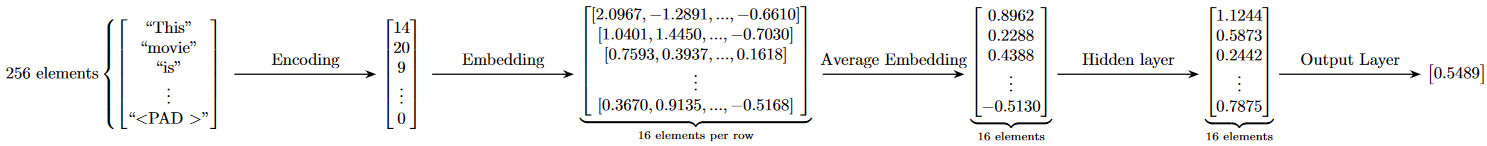

In [ ]:
# Define the cost function to use (copied from 05-01-building-nn)
def cost_func(input, target):
   cost = torch.nn.MSELoss(reduction='sum')
   return cost(input, target)

# Define the accuracy (adapted from 05-01-building-nn)
# model: model to evaluate the accuracy of
# data: numpy arrays containing the data to run through the model
# labels: correct labels for our data
def accuracy(model, data, labels):
  xb = torch.tensor(data)
  yb = torch.tensor(labels)
  pred = model(xb).squeeze()

  num_right = 0
  for i in range(pred.shape[0]):
    guess = round(pred[i].item())
    if guess == labels[i]:
      num_right = num_right + 1

  return num_right / pred.shape[0]


In [ ]:
# We will define a function for training out model (copied and adapted from 05-02-data-nn):
# epochs is the number of times we pass over the complete training set.
# batch_size is how many training examples to combine before updating the model parameters
# learning_rate controls how large of a step we take each time we update the model parameters
# data_train is the list of images we are training on (the entirety of this dataset corresponds to a single epoch)
# label_train is the list of labels corresponding to the images in data_train
# model is the model we are training
# We can optionally pass two additional parameters data_valid and label_valid.

# The function will return a list containing the average cost function after each epoch
def train_model(epochs, batch_size, learning_rate, data_train, label_train, model, data_valid, label_valid):

  # Create lists to return
  cost_valid = []
  cost_train = []
  models = []

  # Create the optimizer to perform the gradient descent
  opt = torch.optim.Adam(model.parameters(), lr=learning_rate)

  # Wrap the training data in a dataset
  train_ds = torch.utils.data.TensorDataset(torch.tensor(data_train), torch.tensor(label_train))
  train_dl = torch.utils.data.DataLoader(train_ds, batch_size=batch_size)

  # We will repeat the training process multiple times, printing the current average of the cost function after each epoch
  for epoch in range (epochs):

    # Each iteration of this loop will evaluate the model
    # on a subset of the data containing batch_size reviews
    for xb, yb in train_dl:
      pred = model(xb).squeeze()
      cost = cost_func(pred, yb.float())

      # Update the model parameters (i.e. train the model)
      # for this batch of data
      opt.zero_grad()
      cost.backward()
      opt.step()

    # End of batch_size loop

    # Copy our current model to return after training
    models.append(copy.deepcopy(model))

    # Calculate the average cost function across all the training data
    xb = torch.tensor(data_train)
    yb = torch.tensor(label_train)
    pred = model(xb).squeeze()
    cost = cost_func(pred, yb) / len(pred)
    cost_train.append(cost.item())
    print(f"After epoch {epoch} the cost function is {cost}")

    xb = torch.tensor(data_valid)
    yb = torch.tensor(label_valid)
    pred = model(xb).squeeze()
    cost_v = cost_func(pred, yb) / len(pred)
    cost_valid.append(cost_v.item())



  return cost_valid, cost_train, models

In [ ]:
# Create the model architecture we will use (modified from 05-01-building-nn)
class IMDBModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.relu = nn.ReLU()
    self.sigmoid = nn.Sigmoid()

    # Create the first layer of the neural network. This layer is responsible for taking our words
    # and encoding their meaning in a 16 element list. This operation is called "embedding" and is
    # what allows us to work with text on a computer where all of our information is numbers.
    # This is roughly equivalent to how we represented our image as a list of numbers between 0 and 1.
    # This embedding layer has 10,000 inputs (the number of unique words in our word mapping) and outputs
    # 16 numbers that encode the meaning of our input word.
    self.embedding = nn.Embedding(vocab_size, 16)

    # This layer is just a mathmatical operation that has no parameters that are adjusted during training.
    # All it does is take our full review and compress it into a single 16 element list of numbers
    # this is like the "average meaning" of the review.
    self.global_avg_pool = nn.AdaptiveAvgPool1d(1)

    # We have now done the required pre-processing to let us work with text. Now we can use our normal
    # hidden layers we have talked about in class

    # Create the first hidden layer which takes in the "average meaning" of the review and has 16 outputs
    # Like in the digit classification, there is nothing special about there being 16 outputs from this layer.
    self.hidden1 = nn.Linear(16, 16)

    # Create our output layer where takes in the output from the last hidden layer and outputs a single
    # number. It should be 1 if it's a positive review and 0 if it is a negative review
    self.output = nn.Linear(16, 1)

  def forward(self, xb):
    # xb is the value of all the neurons at the current layer.
    # At the start it is a tensor with 256 elements corresponding to the words in the review


    # Turn each individual word into a list of 16 numbers.
    xb = self.embedding(xb)
    # xb is now a tensor with 256 elements. Each element is a list of 16 numbers that "encode"
    # the meaning of the word.

    # Take the average the meaning of each of the 256 words
    is_batched = xb.ndim == 3
    if not is_batched:
      xb = torch.unsqueeze(xb, 0)
    xb = self.global_avg_pool(xb.permute(0, 2, 1)).squeeze(-1)  # Global average pooling
    if not is_batched:
        xb = xb.squeeze(0)
    # xb is now a tensor with 16 element that correspond to the 16 numbers that "encode" the
    # average meaning of the review. This is just taking an average of all 256 words.

    # Do the matrix multiplication and then take the sigmoid of each element in the first hidden layer.
    xb = self.relu(self.hidden1(xb))
    # xb is now a tensor with 16 elements

    # Do the matrix multiplication and then take the sigmoid of each element in the output layer.
    xb = self.sigmoid(self.output(xb))
    # xb is now a tensor with 1 element

    return xb

## Exercise 1

The code cell below will train the model using 5000 reviews and plot the cost function as a function of epoch number. With the default hyperparameters (`learning_rate = 0.001, batch_size = 512, num_epochs = 10`) is the model being over- or under-trained? In otherwords, should we train the model for more epochs or should we train the model for fewer epochs? Provide evidence for your conclusion using the graph.

In [ ]:
# Hyperparameters for training
learning_rate = 0.001
batch_size = 512
num_epochs = 10

# This will default to creating a model with random weights and biases.
model = IMDBModel()

# Let's only use a subset of the data for validation purposes
train_data_small = train_data[:5000]
train_labels_small = train_labels[:5000]
valid_data_small = valid_data[:5000]
valid_labels_small = valid_labels[:5000]


# Train the data. Save the average cost function and the model after each epoch
cost_valid, cost_train, models_ex1 = train_model(num_epochs, batch_size, learning_rate, train_data_small, train_labels_small, model, valid_data_small, valid_labels_small)

# plot the cost function as a function of epoch
epochs = [i for i in range(num_epochs)]

fig = plt.figure(figsize=(8,6))
plt.title("Cost function vs. training epoch")
plt.xlabel('Epoch')
plt.ylabel('Cost function (arb)')
plt.grid(which='both', axis='both')
plt.plot(epochs, cost_train, 'r-', label="Training set")
plt.plot(epochs, cost_valid, 'b-', label="Validation set")
plt.legend()
plt.show()


## Exercise 2

Adjust the number of epochs you are training the model for so that we begin to overtrain the model. **How can you tell when the model is being overtrained? Based on your graph, at what epoch should we stop training the model?**

In [ ]:
# Hyperparameters for training
learning_rate = 0.001
batch_size = 512
num_epochs = 10

# This will default to creating a model with random weights and biases.
model = IMDBModel()

# Let's only use a subset of the data for validation purposes
train_data_small = train_data[:5000]
train_labels_small = train_labels[:5000]
valid_data_small = valid_data[:5000]
valid_labels_small = valid_labels[:5000]


# Train the data. Save the average cost function and the model after each epoch
cost_valid, cost_train, models_ex2 = train_model(num_epochs, batch_size, learning_rate, train_data_small, train_labels_small, model, valid_data_small, valid_labels_small)

# plot the cost function as a function of epoch
epochs = [i for i in range(num_epochs)]

fig = plt.figure(figsize=(8,6))
plt.title("Cost function vs. training epoch")
plt.xlabel('Epoch')
plt.ylabel('Cost function (arb)')
plt.grid(which='both', axis='both')
plt.plot(epochs, cost_train, 'r-', label="Training set")
plt.plot(epochs, cost_valid, 'b-', label="Validation set")
plt.legend()
plt.show()

## Exercise 3

The code cell below will calculate and plot the accuracy of the classification for the training and validation sets. Based on your answer to the previous question, do you see evidence of overtraining at the same epoch? Why or why not?

In [ ]:
acc = []
acc_valid = []
for model in models_ex2:
  acc.append(accuracy(model, train_data_small, train_labels_small))
  acc_valid.append(accuracy(model, valid_data_small, valid_labels_small))


print(f"With our best model, our accuracy on the training data is {acc[-1]*100:.2f}%")
print(f"With our best model, our accuracy on the validation data is {acc_valid[-1]*100:.2f}%")

fig = plt.figure(figsize=(8,6))
plt.title("Accuracy vs. training epoch")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(which='both', axis='both')
plt.plot(epochs, acc, 'r-', label="Training set")
plt.plot(epochs, acc_valid, 'b-', label="Validation set")
plt.legend()
plt.show()

## Exercise 4

Adjust the learning rate in the code cell below. How large can you make the learning rate before the model stops training properly? What is happening when we stop being able to properly train the model due to a large learning rate? With your new, larger learning rate at what epoch should we stop training? Why?

In [ ]:
# Hyperparameters for training
learning_rate = 0.001
batch_size = 512
num_epochs = 10

# This will default to creating a model with random weights and biases.
model = IMDBModel()

# Let's only use a subset of the data for validation purposes
train_data_small = train_data[:5000]
train_labels_small = train_labels[:5000]
valid_data_small = valid_data[:5000]
valid_labels_small = valid_labels[:5000]


# Train the data. Save the average cost function and the model after each epoch
cost_valid, cost_train, models_ex4 = train_model(num_epochs, batch_size, learning_rate, train_data_small, train_labels_small, model, valid_data_small, valid_labels_small)

# plot the cost function as a function of epoch
epochs = [i for i in range(num_epochs)]

fig = plt.figure(figsize=(8,6))
plt.title("Cost function vs. training epoch")
plt.xlabel('Epoch')
plt.ylabel('Cost function (arb)')
plt.grid(which='both', axis='both')
plt.plot(epochs, cost_train, 'r-', label="Training set")
plt.plot(epochs, cost_valid, 'b-', label="Validation set")
plt.legend()
plt.show()

acc = []
acc_valid = []
for model in models_ex4:
  acc.append(accuracy(model, train_data_small, train_labels_small))
  acc_valid.append(accuracy(model, valid_data_small, valid_labels_small))


print(f"With our best model, our accuracy on the training data is {acc[-1]*100:.2f}%")
print(f"With our best model, our accuracy on the validation data is {acc_valid[-1]*100:.2f}%")

fig = plt.figure(figsize=(8,6))
plt.title("Accuracy vs. training epoch")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(which='both', axis='both')
plt.plot(epochs, acc, 'r-', label="Training set")
plt.plot(epochs, acc_valid, 'b-', label="Validation set")
plt.legend()
plt.show()

## Exercise 5

Let's test your model on a review you write. Using your answer to the previous exercise, adjust the value of the `epoch_to_stop_training` in the code cell below. This will be used to grab our "best" model to run on your movie review.

In the code cell below, write two movie reviews based on movies you have seen previously. One should be a positive review and one should be a negative review. Does your model properly identify which is which?

In [ ]:
epoch_to_stop_training = 0
trained_model = models_ex4[epoch_to_stop_training]

good_review = "This is some text about a good movie review! Hopefully it works."
bad_review = "This is some text about a bad movie review! Hopefully it works."

# Encode the review using our map
good_encoded = encode_review(good_review)
bad_encoded = encode_review(bad_review)

# Pad the review so it is the proper length
good_encoded = pad_review(good_encoded)
bad_encoded = pad_review(bad_encoded)

# print out the encoded reviews
print(f"Good review: {decode_review(good_encoded)}")
print(f"Bad review: {decode_review(bad_encoded)}")

good_pred = trained_model(torch.tensor(good_encoded))
bad_pred = trained_model(torch.tensor(bad_encoded))

if good_pred > 0.5:
  print(f"The model predicts that the good review is positive")
else:
  print(f"The model predicts that the good review is negative")

if bad_pred > 0.5:
  print(f"The model predicts that the bad review is positive")
else:
  print(f"The model predicts that the bad review is negative")


## Exercise 6

What was your favorite thing we did in this class (unit, class activity, etc.)? What was the thing you enjoyed the least? Why?